# Story B.1 - Basket Rules (Frequent Itemsets / Association Rules)

**Goal:** Mine co-occurrence patterns in viewer behavior using association rule learning.

This notebook produces **frequent itemsets** and **association rules** over user “liked” baskets (tokens). The outputs are written as versioned artifacts (tables + reports + figures) under a **mode-specific folder**, so you can run different configurations without overwriting results.

### Mining input (deliberate mode switch)

This notebook supports a deliberate mode switch for the mining input table:

- **Reduced (default / canonical mining input):** `transactions_train_reduced.parquet`
  - Job: production mining + reproducible artifacts
  - Why: tractable runtime + controlled combinatorics
- **Full (expert / diagnostic mode):** `transactions_train.parquet`
  - Job: audits, A/B sanity checks, “how much did reduction change things?”
  - Why: closest to “ground truth baskets”, but can be computationally expensive

The switch is controlled by `TRANSACTIONS_INPUT = "reduced" | "full"` in the **Parameters** cell.

---

## What you get from a run (outputs)

**Core / key output artifacts**
- Primary “source of truth” (downstream logic + evaluation): tables/association_rules.parquet

**Usually key (depends on consumer)**
- Best for UI / human display (decoded titles/labels): tables/rules_human_readable.parquet

**Supportive / diagnostic**
- Audit mined itemsets (sanity checks, pruning effects): tables/frequent_itemsets.parquet
- Quick narrative + plots for inspection: reports/summary.md and files under figures/

- Provenance / reproducibility (what exactly was run): reports/run_manifest.json


All artifacts are written under:

`data/story-module-outputs/story_b/preset_<PRESET>_<TOKEN_FAMILY_MODE>_<TRANSACTIONS_INPUT>/<RUN_ID>/`

Typical structure:

```
data/story-module-outputs/story_b/preset_<PRESET>_<TOKEN_FAMILY_MODE>_<TRANSACTIONS_INPUT>/<RUN_ID>/
  tables/
    frequent_itemsets.parquet        # mined itemsets (low-support view; used to generate rules)
    association_rules.parquet        # rule metrics (machine-readable)
    rules_human_readable.parquet     # decoded rules (titles/labels for reports/apps)
  reports/
    run_manifest.json                # full configuration + counts + timestamps
    summary.md                       # short narrative summary of the run
  figures/
    *.png                            # diagnostic plots (support/lift, distributions, top rules)
```

### Key tables (quick schema guide)

- `frequent_itemsets.parquet`
  - `itemset`: list of token strings (size 1 or 2)
  - `support`: fraction of baskets containing the itemset
- `association_rules.parquet` (primary output for downstream usage)
  - `antecedent`, `consequent`: list[str] tokens
  - `support`, `confidence`, `lift` (+ other standard metrics)
  - `rule_type`: coarse category based on token families (movie-only / genre-only / tag-only / cross-type)
- `rules_human_readable.parquet`
  - adds decoded strings (e.g., movie titles) so rules can be shown directly in reports/apps

---



## Setup

In [89]:
from __future__ import annotations

import json
import re
import warnings
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from mlxtend.frequent_patterns import fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

warnings.filterwarnings("ignore", category=DeprecationWarning)
plt.style.use("seaborn-v0_8-whitegrid")

print("Imports OK")

Imports OK


## 1 - Parameters 

In [ ]:
import os
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd

#  Paths (relative to repo root)
REPO_ROOT = Path.cwd().parent  # story_modules/ is one level below root
TABLE_DIR = REPO_ROOT / "data" / "preprocessed-data" / "tables"

# -------------------------------------------------------------------
# Deliberate mode switch: reduced vs full transactions
# -------------------------------------------------------------------
TRANSACTIONS_INPUT = "full"  # "reduced" (default) | "full" (diagnostic/expert)
TRANSACTIONS_PATH_OVERRIDE: str | Path | None = None
"""Choose which transaction table Story B.1 mines.

- "reduced": production mining / reproducible artifacts (recommended)
  Reads: transactions_train_reduced.parquet
- "full": diagnostics / audits (can be computationally brutal)
  Reads: transactions_train.parquet

If TRANSACTIONS_PATH_OVERRIDE is set, it is used instead of TABLE_DIR + default filename.
"""

def _default_transactions_filename(kind: str, split: str) -> str:
    if kind not in {"reduced", "full"}:
        raise ValueError(f"TRANSACTIONS_INPUT must be 'reduced' or 'full', got {kind!r}")
    if split not in {"train", "test"}:
        raise ValueError(f"split must be 'train' or 'test', got {split!r}")
    if kind == "reduced":
        return f"transactions_{split}_reduced.parquet"
    return f"transactions_{split}.parquet"

DEFAULT_TRAIN_TRANSACTIONS_FILE = _default_transactions_filename(TRANSACTIONS_INPUT, "train")
DEFAULT_TEST_TRANSACTIONS_FILE = _default_transactions_filename(TRANSACTIONS_INPUT, "test")

#  Fix #4: token-family strategy ─
# TOKEN_FAMILY_MODE controls which token families are allowed into each basket
# **before** singleton support filtering (Fix #3) and one-hot encoding (Fix #1).
# Smaller vocab ⇒ faster mining; broader vocab ⇒ more specific but slower/noisier rules.
#
# Options (what it keeps → typical use / tradeoffs):
#   "mixed_all"               -> movie:* + genre:* + tag:*
#                                 Max expressiveness (all cross-family rules), typically slowest.
#   "genre_only"              -> genre:*
#                                 Fastest & most stable, but coarse (no specific movies).
#   "movie_only"              -> movie:* (movie↔movie rules)
#                                 Item-to-item affinity, but can be sparse/slow; needs strong evidence thresholds.
#   "tag_only"                -> tag:*
#                                 Semantic tag associations; can be noisy depending on tag distribution.
#   "movie_genre"             -> movie:* + genre:*
#                                 Adds genre context to movie rules; still heavy due to large movie vocab.
#   "genre_tag"               -> genre:* + tag:*
#                                 Fast semantic default: interpretable theme/style rules without huge movie tail.
#   "controlled_cross_family" -> genre:* + top-K movie:* + top-K tag:* (by basket-frequency; cross-family rules in a single run)
#                                 Balanced mode: keeps genres plus only the most common movies/tags to control runtime.
#   "controlled_movie_tag"    -> top-K movie:* + top-K tag:* (no genres), with per-basket caps
#                                 Use for explainability runs where you only need movie↔tag pairs and want to avoid genre tokens entirely.
# Pick controlled_cross_family if you want one artifact set and manageable runtime.
# Prefer two separate runs (movie_only + genre_tag) if you need best-quality movie-to-movie rules and best-quality explanation rules (cleaner separation, less interference).

# Presets (tiny, high-impact): pick A, B, or C, or set to "custom" and edit manually below.
RUN_PRESET = "C"  # A=movie↔movie, B=movie↔tag, C=genre↔tag, custom=manual config
RUN_ID = None  # None/"auto" => current UTC timestamp, e.g. 20260226_093015

# Manual defaults (used when RUN_PRESET == "custom")
TOKEN_FAMILY_MODE = "controlled_cross_family"

# Optional: alternative itemset mining path for explainable demos
ITEMSET_MINER = "fpgrowth"
"""Which frequent-itemset miner to use.

- "fpgrowth"       : standard FP-Growth on the (sparse) one-hot matrix.
- "cooc_movie_tag" : build frequent 1- and 2-itemsets for movie↔tag only via sparse co-occurrence counts, then run association_rules on that table.
                   This avoids full FP-growth and is typically much faster for explainability-focused runs.
"""

# Controlled-basket knobs (vocab limits + per-basket caps) ─
# - In TOKEN_FAMILY_MODE="controlled_*": these are ALWAYS applied.
# - In other modes, you can optionally apply them when ITEMSET_MINER="fpgrowth" to get
#   "controlled baskets + fpgrowth" (fast, popularity-biased) vs "full baskets + fpgrowth" (slower, more complete).

# If True, apply TOP_K_MOVIES/TAGS even when TOKEN_FAMILY_MODE is not controlled_* (fpgrowth only).
ENABLE_VOCAB_LIMITS = False

# If True, apply MAX_*_PER_BASKET even when TOKEN_FAMILY_MODE is not controlled_* (fpgrowth only).
ENABLE_BASKET_CAPS = False

# Vocabulary limits (top-K by basket-frequency)
TOP_K_MOVIES = 600
TOP_K_TAGS = 600

# Per-basket caps (prevents fat baskets that explode pair opportunities)
MAX_MOVIES_PER_BASKET = 60
MAX_TAGS_PER_BASKET = 60

#  Mining thresholds
MIN_SUPPORT_HIGH = 0.01  # 1 % of baskets (reporting/view threshold)
MIN_SUPPORT_LOW = 0.001 # actual mining threshold
MIN_CONFIDENCE = 0.4
MIN_LIFT = 1.5
MAX_ITEMSET_LEN = 2  # cap for interpretability
TOP_N_RULES_DISPLAY = 20

# Apply presets (override manual settings)
preset = (RUN_PRESET or "custom").strip().upper()
if preset == "A":
    TOKEN_FAMILY_MODE = "movie_only"
    ITEMSET_MINER = "fpgrowth"
    # Preset A defaults to "full baskets + fpgrowth" (more complete, slower).
    # Flip ENABLE_VOCAB_LIMITS / ENABLE_BASKET_CAPS to True above for a faster, popularity-biased run.

    ENABLE_VOCAB_LIMITS = True
    ENABLE_BASKET_CAPS = True

    # Coverage-oriented defaults for Preset A movie→movie runs.
    TOP_K_MOVIES = 600
    TOP_K_TAGS = 600
    MIN_SUPPORT_LOW = 0.001
    MIN_CONFIDENCE = 0.3

    # Per-basket caps (prevents fat baskets that explode pair opportunities)
    MAX_MOVIES_PER_BASKET = 39
    MAX_TAGS_PER_BASKET = 39

elif preset == "B":
    TOKEN_FAMILY_MODE = "controlled_movie_tag"
    ITEMSET_MINER = "cooc_movie_tag"

    # Not needed for this mode (cooc_movie_tag miner already only looks at movie↔tag pairs, so vocab is effectively limited to that), but set to False explicitly to avoid confusion.
    ENABLE_VOCAB_LIMITS = False
    ENABLE_BASKET_CAPS = False

elif preset == "C":
    # Run C: genre↔tag semantic layer (stable, explainable)
    TOKEN_FAMILY_MODE = "genre_tag"
    ITEMSET_MINER = "fpgrowth"

    # Not needed for this mode (vocab is already small: ~genres + tags)
    ENABLE_VOCAB_LIMITS = False
    ENABLE_BASKET_CAPS = False

    # Coverage-oriented defaults for Preset C genre↔tag semantics.
    MIN_SUPPORT_LOW = 0.005
    MIN_LIFT = 1.2
    MIN_CONFIDENCE = 0.25
elif preset == "CUSTOM":
    pass
else:
    raise ValueError(f"Unsupported RUN_PRESET: {RUN_PRESET!r} (use 'A', 'B', 'C', or 'custom')")

# Safety policy for TRANSACTIONS_INPUT='full' (diagnostic/expert mode)
if TRANSACTIONS_INPUT == "full":
    # Full baskets can be a combinatorial bonfire for FP-growth.
    # Enforce conservative defaults when using fpgrowth to keep runtime tractable.
    if ITEMSET_MINER == "fpgrowth":
        ENABLE_VOCAB_LIMITS = True
        ENABLE_BASKET_CAPS = True
        MIN_SUPPORT_LOW = max(MIN_SUPPORT_LOW, 0.001)
        MIN_SUPPORT_HIGH = max(MIN_SUPPORT_HIGH, 0.01)
        # Keep top-K / caps reasonable unless the preset already made them smaller.
        TOP_K_MOVIES = min(TOP_K_MOVIES, 600)
        TOP_K_TAGS = min(TOP_K_TAGS, 600)
        MAX_MOVIES_PER_BASKET = min(MAX_MOVIES_PER_BASKET, 60)
        MAX_TAGS_PER_BASKET = min(MAX_TAGS_PER_BASKET, 60)

# Resolve run_id (timestamp-based output namespace)
if RUN_ID is None or str(RUN_ID).strip() == "" or str(RUN_ID).strip().lower() == "auto":
    RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S")
else:
    RUN_ID = str(RUN_ID).strip()

# Derived: are controls active in THIS run?
VOCAB_LIMITS_ACTIVE = TOKEN_FAMILY_MODE.startswith("controlled_") or (ITEMSET_MINER == "fpgrowth" and ENABLE_VOCAB_LIMITS)
BASKET_CAPS_ACTIVE = TOKEN_FAMILY_MODE.startswith("controlled_") or (ITEMSET_MINER == "fpgrowth" and ENABLE_BASKET_CAPS)

# Output directory layout:
OUT_RUN_ROOT = REPO_ROOT / "data" / "story-module-outputs" / f"story_b" / f"preset_{preset}_{TOKEN_FAMILY_MODE}_{TRANSACTIONS_INPUT}"
OUT_ROOT = OUT_RUN_ROOT / f"{RUN_ID}"

OUT_TABLES = OUT_ROOT / "tables"
OUT_REPORTS = OUT_ROOT / "reports"
OUT_FIGURES = OUT_ROOT / "figures"

for d in [OUT_TABLES, OUT_REPORTS, OUT_FIGURES]:
    d.mkdir(parents=True, exist_ok=True)

# Human-friendly label used in prints/reports
RUN_LABEL = f"preset_{preset}_{TOKEN_FAMILY_MODE}_{TRANSACTIONS_INPUT}/{RUN_ID}"

# Tip: preset B (movie↔tag explainability) often needs a lower MIN_SUPPORT_LOW than preset A,
# because movie↔tag pairs are typically rarer than genre↔tag patterns.

#  Association Rule Quality Framework (optional quality gates) ─
ENABLE_GATE_1 = False  # Evidence & non-triviality
ENABLE_GATE_2 = False  # Test stability validation

# Gate 1 (train evidence)
MIN_COUNT_AB_TRAIN = 50
MIN_COUNT_A_TRAIN = 100
MAX_SUPP_B_TRAIN = 0.20  # set to None to disable popularity cap

# Gate 2 (test stability)
MIN_CONF_TEST = 0.10
MIN_CONF_RATIO = 0.80
MIN_COUNT_AB_TEST = 50

# Expected filename for Gate 2 (if present in TABLE_DIR)
TEST_TRANSACTIONS_FILE = DEFAULT_TEST_TRANSACTIONS_FILE

#  Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print(f"TABLE_DIR : {TABLE_DIR}")
print(f"TRANSACTIONS_INPUT: {TRANSACTIONS_INPUT}")
print(f"DEFAULT_TRAIN_TRANSACTIONS_FILE: {DEFAULT_TRAIN_TRANSACTIONS_FILE}")
print(f"RUN_ID   : {RUN_ID}")
print(f"RUN_LABEL: {RUN_LABEL}")
print(f"OUT_RUN_ROOT: {OUT_RUN_ROOT}")
print(f"OUT_ROOT  : {OUT_ROOT}")
print(f"RUN_PRESET : {RUN_PRESET}")
print(f"TOKEN_FAMILY_MODE : {TOKEN_FAMILY_MODE}")
print(f"ITEMSET_MINER : {ITEMSET_MINER}")
print(f"CONTROL_TOGGLES (fpgrowth only): ENABLE_VOCAB_LIMITS={ENABLE_VOCAB_LIMITS}, ENABLE_BASKET_CAPS={ENABLE_BASKET_CAPS}")
print(f"CONTROL_ACTIVE: vocab_limits={VOCAB_LIMITS_ACTIVE}, basket_caps={BASKET_CAPS_ACTIVE}")
print(f"GATES: gate1={ENABLE_GATE_1}, gate2={ENABLE_GATE_2}")
if VOCAB_LIMITS_ACTIVE:
    print(f"TOP_K_MOVIES={TOP_K_MOVIES}, TOP_K_TAGS={TOP_K_TAGS}")
if BASKET_CAPS_ACTIVE:
    print(f"CAPS: MAX_MOVIES_PER_BASKET={MAX_MOVIES_PER_BASKET}, MAX_TAGS_PER_BASKET={MAX_TAGS_PER_BASKET}")

TABLE_DIR : /mnt/d/mse/nguyen_sy_hung_codebases/movielens-story-modules-b/data/preprocessed-data/tables
TRANSACTIONS_INPUT: full
DEFAULT_TRAIN_TRANSACTIONS_FILE: transactions_train.parquet
RUN_ID   : 20260227_043426
RUN_LABEL: preset_C_genre_tag_full/20260227_043426
OUT_RUN_ROOT: /mnt/d/mse/nguyen_sy_hung_codebases/movielens-story-modules-b/data/story-module-outputs/story_b/preset_C_genre_tag_full
OUT_ROOT  : /mnt/d/mse/nguyen_sy_hung_codebases/movielens-story-modules-b/data/story-module-outputs/story_b/preset_C_genre_tag_full/20260227_043426
RUN_PRESET : C
TOKEN_FAMILY_MODE : genre_tag
ITEMSET_MINER : fpgrowth
CONTROL_TOGGLES (fpgrowth only): ENABLE_VOCAB_LIMITS=True, ENABLE_BASKET_CAPS=True
CONTROL_ACTIVE: vocab_limits=True, basket_caps=True
GATES: gate1=False, gate2=False
TOP_K_MOVIES=600, TOP_K_TAGS=600
CAPS: MAX_MOVIES_PER_BASKET=60, MAX_TAGS_PER_BASKET=60


## 2 - Load data

In [91]:
#  Primary mining input: choose reduced vs full baskets via TRANSACTIONS_INPUT
if TRANSACTIONS_PATH_OVERRIDE is not None and str(TRANSACTIONS_PATH_OVERRIDE).strip() != "":
    transactions_path = Path(TRANSACTIONS_PATH_OVERRIDE)
    if not transactions_path.is_absolute():
        transactions_path = (REPO_ROOT / transactions_path).resolve()
else:
    transactions_path = TABLE_DIR / DEFAULT_TRAIN_TRANSACTIONS_FILE

if not transactions_path.exists():
    raise FileNotFoundError(f"Transactions file not found: {transactions_path}")

transactions = pd.read_parquet(transactions_path)

print(f"Transactions input : {TRANSACTIONS_INPUT}")
print(f"Transactions path  : {transactions_path}")
print(f"Baskets loaded     : {len(transactions):,}")
print(f"Columns            : {list(transactions.columns)}")
print(f"Median basket size : {transactions['n_items'].median():.0f}")
print(f"Mean basket size   : {transactions['n_items'].mean():.1f}")
transactions.head(3)

Transactions input : full
Transactions path  : /mnt/d/mse/nguyen_sy_hung_codebases/movielens-story-modules-b/data/preprocessed-data/tables/transactions_train.parquet
Baskets loaded     : 316,347
Columns            : ['userId', 'items', 'n_items']
Median basket size : 31
Mean basket size   : 61.6


,userId,items,n_items
0,1,"[genre:action, genre:adventure, genre:animatio...",51
1,2,"[genre:action, genre:adventure, genre:animatio...",53
2,3,"[genre:action, genre:adventure, genre:animatio...",42


In [92]:
#  Verify vocabulary size 
all_tokens = transactions["items"].explode().dropna()
vocab = all_tokens.unique()
vocab_size = len(vocab)

# Token family breakdown
families = pd.Series(vocab).apply(lambda t: t.split(":", 1)[0] if ":" in t else "unknown")
family_counts = families.value_counts()

print(f"Total unique tokens (vocab) : {vocab_size:,}")
print(f"\nToken families:")
for fam, cnt in family_counts.items():
    print(f"  {fam:>10s} : {cnt:,}")

Total unique tokens (vocab) : 66,979

Token families:
       movie : 50,518
         tag : 16,442
       genre : 19


In [93]:
#  Lookup table for decoding movie:<id> tokens 
movies = pd.read_parquet(TABLE_DIR / "dim_movies_clean.parquet")
print(f"Movies loaded : {len(movies):,} rows")
print(f"Columns       : {list(movies.columns)}")
movies.head(3)

Movies loaded : 86,537 rows
Columns       : ['movieId', 'title', 'year', 'genres', 'genres_list']


,movieId,title,year,genres,genres_list
0,1,Toy Story (1995),1995,Adventure|Animation|Children|Comedy|Fantasy,"[Adventure, Animation, Children, Comedy, Fantasy]"
1,2,Jumanji (1995),1995,Adventure|Children|Fantasy,"[Adventure, Children, Fantasy]"
2,3,Grumpier Old Men (1995),1995,Comedy|Romance,"[Comedy, Romance]"


## 3 - Prepare baskets for mlxtend

We convert the Parquet `items` column into a Python list-of-lists, then apply the key performance/sanity steps **before** one-hot encoding:

- **Fix #4 (token-family strategy):** restrict tokens to the families you want (biggest speed lever)
- **Fix #5 (vocab limits + per-basket caps):** in `controlled_*` modes these are always on; in other modes you can enable them via `ENABLE_VOCAB_LIMITS` / `ENABLE_BASKET_CAPS` when using `fpgrowth` to get “controlled baskets + fpgrowth”
- **Fix #3 (mandatory singleton pruning):** drop items with count `< ceil(MIN_SUPPORT_LOW * N_baskets)` (safe for pair mining)

After that, we one-hot encode with `TransactionEncoder(..., sparse=True)` (Fix #1).

In [94]:
%%time
# Convert items column to list-of-lists
baskets: list[list[str]] = transactions["items"].tolist()

from collections import Counter


def _token_family(token: str) -> str:
    return token.split(":", 1)[0] if ":" in token else "unknown"


def _apply_family_mode(baskets_in: list[list[str]]) -> list[list[str]]:
    """Apply Fix #4 family strategy before any support filtering.

    Note: "controlled_*" modes always apply TOP_K_* and MAX_*_PER_BASKET controls.
    For non-controlled modes, these controls can be toggled on for fpgrowth via
    VOCAB_LIMITS_ACTIVE / BASKET_CAPS_ACTIVE (see Parameters cell).
    """
    mode = TOKEN_FAMILY_MODE

    # 1) Base family filtering (defines semantic scope)
    if mode == "mixed_all":
        baskets_mode = baskets_in
    elif mode == "genre_only":
        baskets_mode = [[t for t in b if t.startswith("genre:")] for b in baskets_in]
    elif mode == "movie_only":
        baskets_mode = [[t for t in b if t.startswith("movie:")] for b in baskets_in]
    elif mode == "tag_only":
        baskets_mode = [[t for t in b if t.startswith("tag:")] for b in baskets_in]
    elif mode == "movie_genre":
        baskets_mode = [[t for t in b if t.startswith("movie:") or t.startswith("genre:")] for b in baskets_in]
    elif mode == "genre_tag":
        baskets_mode = [[t for t in b if t.startswith("genre:") or t.startswith("tag:")] for b in baskets_in]
    elif mode == "controlled_cross_family":
        baskets_mode = [[t for t in b if (t.startswith("movie:") or t.startswith("genre:") or t.startswith("tag:"))] for b in baskets_in]
    elif mode == "controlled_movie_tag":
        baskets_mode = [[t for t in b if (t.startswith("movie:") or t.startswith("tag:"))] for b in baskets_in]
    else:
        raise ValueError(f"Unsupported TOKEN_FAMILY_MODE: {mode}")

    # 2) Optional controls: vocab limits (TOP_K_*) and per-basket caps (MAX_*_PER_BASKET)
    if VOCAB_LIMITS_ACTIVE or BASKET_CAPS_ACTIVE:
        # Basket-frequency counts (one vote per basket). Used for top-K selection and cap scoring.
        df_counts = Counter(t for b in baskets_in for t in set(b))

        def _top_k_set(prefix: str, k: int | None) -> set[str] | None:
            if k is None or k <= 0:
                return None
            ranked = sorted(
                [(tok, c) for tok, c in df_counts.items() if tok.startswith(prefix)],
                key=lambda x: (-x[1], x[0]),
            )[:k]
            return {tok for tok, _ in ranked}

        top_movies = _top_k_set("movie:", TOP_K_MOVIES) if VOCAB_LIMITS_ACTIVE else None
        top_tags = _top_k_set("tag:", TOP_K_TAGS) if VOCAB_LIMITS_ACTIVE else None

        if VOCAB_LIMITS_ACTIVE:
            print(
                "Vocab limits active: "
                f"TOP_K_MOVIES={TOP_K_MOVIES} (kept={len(top_movies) if top_movies is not None else 0}), "
                f"TOP_K_TAGS={TOP_K_TAGS} (kept={len(top_tags) if top_tags is not None else 0})"
            )

        def _cap_by_global_frequency(tokens: list[str], cap: int | None) -> list[str]:
            if cap is None or cap <= 0 or len(tokens) <= cap:
                return tokens
            scored = [(t, df_counts.get(t, 0)) for t in tokens]
            scored = sorted(scored, key=lambda x: (-x[1], x[0]))
            return [t for t, _ in scored[:cap]]

        n_movie_capped = 0
        n_tag_capped = 0
        max_movies_before = 0
        max_tags_before = 0

        baskets_out: list[list[str]] = []
        for b in baskets_mode:
            genres = [t for t in b if t.startswith("genre:")]
            movies = [t for t in b if t.startswith("movie:")]
            tags = [t for t in b if t.startswith("tag:")]

            if VOCAB_LIMITS_ACTIVE:
                if top_movies is not None:
                    movies = [t for t in movies if t in top_movies]
                if top_tags is not None:
                    tags = [t for t in tags if t in top_tags]

            # Ensure uniqueness within-family before capping (safety)
            movies = list(dict.fromkeys(movies))
            tags = list(dict.fromkeys(tags))

            if BASKET_CAPS_ACTIVE:
                max_movies_before = max(max_movies_before, len(movies))
                max_tags_before = max(max_tags_before, len(tags))
                if MAX_MOVIES_PER_BASKET is not None and len(movies) > MAX_MOVIES_PER_BASKET:
                    n_movie_capped += 1
                if MAX_TAGS_PER_BASKET is not None and len(tags) > MAX_TAGS_PER_BASKET:
                    n_tag_capped += 1

                movies = _cap_by_global_frequency(movies, MAX_MOVIES_PER_BASKET)
                tags = _cap_by_global_frequency(tags, MAX_TAGS_PER_BASKET)

            selected = genres + movies + tags
            selected = list(dict.fromkeys(selected))
            baskets_out.append(selected)

        if BASKET_CAPS_ACTIVE:
            print(
                f"Per-basket caps ({mode}): "
                f"movie capped in {n_movie_capped:,}/{len(baskets_mode):,} baskets (max before={max_movies_before}); "
                f"tag capped in {n_tag_capped:,}/{len(baskets_mode):,} baskets (max before={max_tags_before})"
            )

        baskets_mode = baskets_out

    # Remove empties after family filtering / controls
    baskets_mode = [b for b in baskets_mode if b]
    return baskets_mode


def _distinct_tokens(baskets_in: list[list[str]]) -> set[str]:
    # Use set(b) so each basket contributes at most one vote per token.
    return {t for b in baskets_in for t in set(b)}


def _singleton_prune_to_support(
    baskets_in: list[list[str]],
    min_support: float,
    *,
    label: str,
) -> tuple[list[list[str]], set[str], Counter]:
    """Mandatory singleton pruning: drop items that cannot reach min_support.

    Mathematically safe for 2-itemset mining at the same support:
    if an item isn't frequent alone, it cannot appear in any frequent pair.
    """
    n_baskets = len(baskets_in)
    required_count = int(np.ceil(min_support * n_baskets))
    cnt = Counter(t for b in baskets_in for t in set(b))  # one vote per basket
    keep = {t for t, c in cnt.items() if c >= required_count}

    baskets_out = [[t for t in b if t in keep] for b in baskets_in]
    baskets_out = [b for b in baskets_out if b]  # safety
    print(
        f"Singleton prune ({label}): min_support={min_support} ⇒ required_count=ceil({min_support}*{n_baskets})={required_count}; kept={len(keep):,}/{len(cnt):,} tokens"
    )
    return baskets_out, keep, cnt


# 1) Apply Fix #4 family strategy (plus optional vocab limits/caps)
baskets_mode = _apply_family_mode(baskets)

# 2) Mandatory singleton pruning (Fix #3, stricter via ceil)
baskets_f, keep, cnt = _singleton_prune_to_support(baskets_mode, MIN_SUPPORT_LOW, label="mode")

# 3) Diagnostics (distinct tokens + family composition)
tokens_raw = _distinct_tokens(baskets)
tokens_mode = _distinct_tokens(baskets_mode)
tokens_after = _distinct_tokens(baskets_f)

family_raw = Counter(_token_family(t) for t in tokens_raw)
family_mode = Counter(_token_family(t) for t in tokens_mode)
family_after = Counter(_token_family(t) for t in tokens_after)

n_mode = len(baskets_mode)
required_count = int(np.ceil(MIN_SUPPORT_LOW * n_mode))

print(f"TOKEN_FAMILY_MODE                 : {TOKEN_FAMILY_MODE}")
print(f"Number of baskets (raw)           : {len(baskets):,}")
print(f"Number of baskets (after mode)    : {len(baskets_mode):,}")
print(f"Number of baskets (after filter)  : {len(baskets_f):,}")
print(f"Support threshold (count, mode baskets): ceil({MIN_SUPPORT_LOW} * {n_mode:,}) = {required_count:,}")

print("\nDistinct token counts:")
print(f"  Raw tokens        : {len(tokens_raw):,}")
print(f"  After family mode : {len(tokens_mode):,}")
print(f"  After support     : {len(tokens_after):,}")
print(f"  Kept tokens (keep): {len(keep):,}")

print("\nFamily composition (distinct tokens):")
def _print_family(counter: Counter, label: str) -> None:
    print(f"  {label}:")
    for fam, c in sorted(counter.items(), key=lambda x: x[0]):
        print(f"    {fam:>8s}: {c:,}")

_print_family(family_raw,  "raw")
_print_family(family_mode, "mode")
_print_family(family_after, "after support")

print(f"\nSample basket_f[0]                : {baskets_f[0][:8]}{'...' if len(baskets_f[0]) > 8 else ''}")

Vocab limits active: TOP_K_MOVIES=600 (kept=600), TOP_K_TAGS=600 (kept=600)
Per-basket caps (genre_tag): movie capped in 0/316,347 baskets (max before=0); tag capped in 1,022/316,347 baskets (max before=537)
Singleton prune (mode): min_support=0.01 ⇒ required_count=ceil(0.01*316336)=3164; kept=19/619 tokens
TOKEN_FAMILY_MODE                 : genre_tag
Number of baskets (raw)           : 316,347
Number of baskets (after mode)    : 316,336
Number of baskets (after filter)  : 316,335
Support threshold (count, mode baskets): ceil(0.01 * 316,336) = 3,164

Distinct token counts:
  Raw tokens        : 66,979
  After family mode : 619
  After support     : 19
  Kept tokens (keep): 19

Family composition (distinct tokens):
  raw:
       genre: 19
       movie: 50,518
         tag: 16,442
  mode:
       genre: 19
         tag: 600
  after support:
       genre: 19

Sample basket_f[0]                : ['genre:action', 'genre:adventure', 'genre:animation', 'genre:children', 'genre:comedy', 'genre

In [95]:
%%time
# Fix #1: sparse one-hot encoding with TransactionEncoder
te = TransactionEncoder()
X = te.fit(baskets_f).transform(baskets_f, sparse=True)

# Silence FutureWarning: Allowing arbitrary scalar fill_value in SparseDtype is deprecated
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=FutureWarning, message="Allowing arbitrary scalar fill_value")
    basket_df = pd.DataFrame.sparse.from_spmatrix(X, columns=te.columns_)

sparsity = 1 - (basket_df.sparse.to_coo().nnz / (basket_df.shape[0] * basket_df.shape[1]))
print("One-hot matrix shape:", basket_df.shape)
print("Sparsity:", f"{sparsity:.6f}")
print("Non-zeros:", f"{basket_df.sparse.to_coo().nnz:,}")
basket_df.head(3)

One-hot matrix shape: (316335, 19)
Sparsity: 0.363557
Non-zeros: 3,825,255
CPU times: user 649 ms, sys: 34.1 ms, total: 683 ms
Wall time: 673 ms


,genre:action,genre:adventure,genre:animation,genre:children,genre:comedy,genre:crime,genre:documentary,genre:drama,genre:fantasy,genre:film_noir,genre:horror,genre:imax,genre:musical,genre:mystery,genre:romance,genre:sci_fi,genre:thriller,genre:war,genre:western
0,True,True,True,True,True,True,0,True,True,0,True,0,True,True,True,True,True,True,0
1,True,True,True,True,True,True,0,True,True,0,True,True,True,True,True,True,True,True,True
2,True,True,True,True,True,True,0,True,True,0,True,True,0,True,True,True,True,True,True


## 4 - Frequent itemset mining (pairs only)

We produce frequent 1- and 2-itemsets at `MIN_SUPPORT_LOW` and cap itemset size with `MAX_ITEMSET_LEN=2` for interpretability.

Two supported paths (selected by `ITEMSET_MINER`):

- `"fpgrowth"`: standard FP-Growth on the sparse one-hot matrix
- `"cooc_movie_tag"`: fast movie↔tag co-occurrence mining (builds frequent 1- and 2-itemsets directly, then feeds them into `association_rules`)

We still derive the “high support” view by filtering the resulting itemsets (no second mining pass):

- **Low-support view** (`MIN_SUPPORT_LOW`): more itemsets, finer-grained patterns
- **High-support view** (`MIN_SUPPORT_HIGH`): subset of low-support itemsets, more stable patterns

In [96]:
%%time
# Frequent itemset mining (pairs only)
if ITEMSET_MINER == "fpgrowth":
    # Fix #2: run FP-Growth once at low support
    freq_low = fpgrowth(
        basket_df,
        min_support=MIN_SUPPORT_LOW,
        use_colnames=True,
        max_len=MAX_ITEMSET_LEN,
    )
elif ITEMSET_MINER == "cooc_movie_tag": # fast path for explainability-focused runs where you only need movie↔tag pairs and want to avoid genre tokens entirely.
    # Build frequent 1- and 2-itemsets for movie↔tag only via sparse co-occurrence counts,
    # then feed that into association_rules(). This avoids full FP-growth for explainability runs.
    n_baskets = basket_df.shape[0]
    required_count = int(np.ceil(MIN_SUPPORT_LOW * n_baskets))

    cols = np.array(te.columns_)
    movie_idx = np.where(np.char.startswith(cols.astype(str), "movie:"))[0]
    tag_idx = np.where(np.char.startswith(cols.astype(str), "tag:"))[0]

    if len(movie_idx) == 0 or len(tag_idx) == 0:
        raise ValueError(
            f"ITEMSET_MINER='cooc_movie_tag' requires both movie:* and tag:* tokens after filtering; got movies={len(movie_idx)}, tags={len(tag_idx)}"
        )

    Xm = X[:, movie_idx]
    Xt = X[:, tag_idx]

    # Singleton supports (counts are #baskets containing token)
    movie_counts = np.asarray(Xm.sum(axis=0)).ravel().astype(int)
    tag_counts = np.asarray(Xt.sum(axis=0)).ravel().astype(int)

    movie_tokens = cols[movie_idx].tolist()
    tag_tokens = cols[tag_idx].tolist()

    rows: list[dict] = []
    for tok, c in zip(movie_tokens, movie_counts):
        if c >= required_count:
            rows.append({"support": float(c / n_baskets), "itemsets": frozenset([str(tok)])})
    for tok, c in zip(tag_tokens, tag_counts):
        if c >= required_count:
            rows.append({"support": float(c / n_baskets), "itemsets": frozenset([str(tok)])})

    # Co-occurrence counts for movie↔tag pairs
    # IMPORTANT: Xm/Xt are boolean sparse matrices; SciPy matmul on bool returns bool (any co-occur), not counts.
    # Cast to integers so the product yields true co-occurrence counts (number of baskets containing both).
    cooc = (Xm.astype(np.int32).T @ Xt.astype(np.int32)).tocoo()
    for i, j, c in zip(cooc.row, cooc.col, cooc.data):
        c_int = int(c)
        if c_int >= required_count:
            rows.append(
                {
                    "support": float(c_int / n_baskets),
                    "itemsets": frozenset([str(movie_tokens[i]), str(tag_tokens[j])]),
                }
            )

    freq_low = pd.DataFrame(rows)
else:
    raise ValueError(f"Unsupported ITEMSET_MINER: {ITEMSET_MINER}")

freq_low["length"] = freq_low["itemsets"].apply(len)

# Derive high-support subset by filtering (no second mining pass)
freq_high = freq_low[freq_low["support"] >= MIN_SUPPORT_HIGH].copy()

print(f"ITEMSET_MINER={ITEMSET_MINER}")
print(f"Frequent itemsets (support ≥ {MIN_SUPPORT_LOW}) : {len(freq_low):,}")
print(f"Frequent itemsets (support ≥ {MIN_SUPPORT_HIGH}) : {len(freq_high):,}")
print(f"\nLow-support by length:")
print(freq_low["length"].value_counts().sort_index().to_string())
freq_high.sort_values("support", ascending=False).head(10)

ITEMSET_MINER=fpgrowth
Frequent itemsets (support ≥ 0.01) : 190
Frequent itemsets (support ≥ 0.01) : 190

Low-support by length:
length
1     19
2    171
CPU times: user 1.53 s, sys: 4.15 ms, total: 1.53 s
Wall time: 1.47 s


,support,itemsets,length
0,0.952560,(genre:drama),1
1,0.891520,(genre:comedy),1
2,0.865652,(genre:action),1
19,0.861846,"(genre:comedy, genre:drama)",2
3,0.861166,(genre:thriller),1
4,0.840346,(genre:adventure),1
22,0.837561,"(genre:thriller, genre:drama)",2
20,0.834720,"(genre:action, genre:drama)",2
5,0.816375,(genre:crime),1
25,0.810691,"(genre:adventure, genre:drama)",2


### 4b - High-support subset statistics

This section reports how many itemsets remain after filtering `freq_low` to `support ≥ MIN_SUPPORT_HIGH`.

In [97]:
# Derived high-support subset stats (already computed from freq_low)
print(f"High-support itemsets (support ≥ {MIN_SUPPORT_HIGH}) : {len(freq_high):,}")
print(f"Low-support itemsets  (support ≥ {MIN_SUPPORT_LOW})  : {len(freq_low):,}")
print(f"\nAdditional itemsets from lowering threshold: {len(freq_low) - len(freq_high):,}")

print("\nHigh-support by length:")
print(freq_high["length"].value_counts().sort_index().to_string())

High-support itemsets (support ≥ 0.01) : 190
Low-support itemsets  (support ≥ 0.01)  : 190

Additional itemsets from lowering threshold: 0

High-support by length:
length
1     19
2    171


## 5 - Generate association rules

We generate rules from the **low-support** itemsets (finer-grained), then filter candidates by:

- `confidence ≥ MIN_CONFIDENCE`
- `lift > MIN_LIFT`

These thresholds apply regardless of whether itemsets came from FP-Growth or the movie↔tag co-occurrence miner.

In [98]:
%%time
rules_all = association_rules(
    freq_low,
    metric="confidence",
    min_threshold=MIN_CONFIDENCE,
    num_itemsets=len(baskets_f),
)

# Candidate rules (broad filter: confidence + lift)
print(f"Rules before lift filter : {len(rules_all):,}")
rules_candidates = rules_all[rules_all["lift"] > MIN_LIFT].copy()
rules_candidates = rules_candidates.sort_values("lift", ascending=False).reset_index(drop=True)

# Keep `rules` for downstream cells (it will be overwritten by the gates cell if enabled)
rules = rules_candidates.copy()

print(f"Rules after  lift > {MIN_LIFT}  : {len(rules_candidates):,}")
print(f"\nMetric ranges (candidates):")
for col in ["support", "confidence", "lift", "leverage", "conviction"]:
    if col in rules_candidates.columns:
        print(f"  {col:>12s}: [{rules_candidates[col].min():.4f}, {rules_candidates[col].max():.4f}]")

Rules before lift filter : 305
Rules after  lift > 1.5  : 17

Metric ranges (candidates):
       support: [0.0980, 0.5137]
    confidence: [0.4100, 0.9372]
          lift: [1.5123, 2.5580]
      leverage: [0.0519, 0.1892]
    conviction: [1.3300, 6.4999]
CPU times: user 8.28 ms, sys: 8 μs, total: 8.29 ms
Wall time: 8.78 ms


## 5.5 - Rule Quality Gates (optional)

Association-rule mining produces **candidates**. This section optionally applies two quality gates:

- **Gate 1 (Evidence & non-triviality):** requires minimum co-occurrence evidence and optionally caps overly-popular consequents.
- **Gate 2 (Test stability):** re-evaluates the same rules on a held-out test set (if available) and keeps only stable rules.

Toggle via `ENABLE_GATE_1` and `ENABLE_GATE_2` in the Parameters section.

In [ ]:
%%time
# Candidate rules (min_confidence + lift filters already applied in prior cell)
rules_candidates = rules.copy()
n_train = basket_df.shape[0]

# Helper: extract single tokens for k=2 rules (antecedent and consequent should be singletons)
def _singleton_token(fs: frozenset) -> str | None:
    if not isinstance(fs, frozenset):
        fs = frozenset(fs)
    if len(fs) != 1:
        return None
    return next(iter(fs))

# Precompute train counts from sparse matrix X (counts are #baskets containing token)
col_index = {tok: i for i, tok in enumerate(te.columns_)}
col_sums_train = np.asarray(X.sum(axis=0)).ravel().astype(int)

def _count_token_train(tok: str) -> int:
    i = col_index.get(tok)
    return int(col_sums_train[i]) if i is not None else 0

def _count_pair_train(a: str, b: str) -> int:
    ia = col_index.get(a)
    ib = col_index.get(b)
    if ia is None or ib is None:
        return 0
    return int(X[:, ia].multiply(X[:, ib]).sum())

# Add train evidence columns
rules_q = rules_candidates.copy()
rules_q["A"] = rules_q["antecedents"].apply(_singleton_token)
rules_q["B"] = rules_q["consequents"].apply(_singleton_token)
rules_q = rules_q.dropna(subset=["A", "B"]).reset_index(drop=True)

rules_q["count_A_train"] = rules_q["A"].apply(_count_token_train)
rules_q["count_B_train"] = rules_q["B"].apply(_count_token_train)
rules_q["count_AB_train"] = rules_q.apply(lambda r: _count_pair_train(r["A"], r["B"]), axis=1)

rules_q["support_A_train"] = rules_q["count_A_train"] / n_train
rules_q["support_B_train"] = rules_q["count_B_train"] / n_train
rules_q["support_AB_train"] = rules_q["count_AB_train"] / n_train
rules_q["confidence_train"] = rules_q.apply(
    lambda r: (r["count_AB_train"] / r["count_A_train"]) if r["count_A_train"] > 0 else 0.0, axis=1
 )
rules_q["lift_train"] = rules_q.apply(
    lambda r: (r["confidence_train"] / r["support_B_train"]) if r["support_B_train"] > 0 else 0.0, axis=1
 )

print(f"Candidate rules (post mining thresholds): {len(rules_q):,}")

#  Gate 1: Evidence & non-triviality ─
rules_g1 = rules_q.copy()
if ENABLE_GATE_1:
    mask = (rules_g1["count_AB_train"] >= MIN_COUNT_AB_TRAIN) & (rules_g1["count_A_train"] >= MIN_COUNT_A_TRAIN)
    if MAX_SUPP_B_TRAIN is not None:
        mask = mask & (rules_g1["support_B_train"] <= MAX_SUPP_B_TRAIN)
    rules_g1 = rules_g1[mask].copy()
    print(f"After Gate 1 (evidence/popularity): {len(rules_g1):,}")
else:
    print("Gate 1 disabled → no filtering")

#  Gate 2: Test stability (if test file exists) 
rules_g2 = rules_g1.copy()
gate2_ran = False
test_path = TABLE_DIR / TEST_TRANSACTIONS_FILE
if ENABLE_GATE_2:
    if not test_path.exists():
        print(f"Gate 2 enabled but test file not found: {test_path}")
        print("Skipping Gate 2; keeping Gate 1 output.")
    else:
        gate2_ran = True
        transactions_test = pd.read_parquet(test_path)
        baskets_test = transactions_test["items"].tolist()
        # Apply the same family mode, then restrict to the *train-kept* tokens
        baskets_test_mode = _apply_family_mode(baskets_test)
        baskets_test_f = [[t for t in b if t in keep] for b in baskets_test_mode]
        baskets_test_f = [b for b in baskets_test_f if b]
        n_test = len(baskets_test_f)
        if n_test == 0:
            print("Gate 2: no non-empty test baskets after filtering; skipping.")
        else:
            X_test = te.transform(baskets_test_f, sparse=True)
            col_sums_test = np.asarray(X_test.sum(axis=0)).ravel().astype(int)

            def _count_token_test(tok: str) -> int:
                i = col_index.get(tok)
                return int(col_sums_test[i]) if i is not None else 0

            def _count_pair_test(a: str, b: str) -> int:
                ia = col_index.get(a)
                ib = col_index.get(b)
                if ia is None or ib is None:
                    return 0
                return int(X_test[:, ia].multiply(X_test[:, ib]).sum())

            rules_g2["count_A_test"] = rules_g2["A"].apply(_count_token_test)
            rules_g2["count_B_test"] = rules_g2["B"].apply(_count_token_test)
            rules_g2["count_AB_test"] = rules_g2.apply(lambda r: _count_pair_test(r["A"], r["B"]), axis=1)

            rules_g2["support_B_test"] = rules_g2["count_B_test"] / n_test
            rules_g2["confidence_test"] = rules_g2.apply(
                lambda r: (r["count_AB_test"] / r["count_A_test"]) if r["count_A_test"] > 0 else 0.0, axis=1
            )
            rules_g2["lift_test"] = rules_g2.apply(
                lambda r: (r["confidence_test"] / r["support_B_test"]) if r["support_B_test"] > 0 else 0.0, axis=1
            )
            rules_g2["conf_ratio"] = rules_g2.apply(
                lambda r: (r["confidence_test"] / r["confidence_train"]) if r["confidence_train"] > 0 else 0.0, axis=1
            )

            stable_mask = (rules_g2["confidence_test"] >= MIN_CONF_TEST) & (rules_g2["conf_ratio"] >= MIN_CONF_RATIO) & (rules_g2["count_AB_test"] >= MIN_COUNT_AB_TEST)
            rules_g2 = rules_g2[stable_mask].copy()
            print(f"Gate 2 ran on: {test_path.name} | n_test_baskets={n_test:,}")
            print(f"After Gate 2 (test stability): {len(rules_g2):,}")
else:
    print("Gate 2 disabled → no test validation")

#  Final rules table used for the rest of the notebook ─
rules_final = rules_g2.copy()

# Preset C contract: keep only genre↔tag rules (drop genre↔genre / tag↔tag)
if preset == "C":
    def _is_genre_tag_rule(row: pd.Series) -> bool:
        a = set(row.get("antecedents", []))
        b = set(row.get("consequents", []))
        a_has_genre = any(isinstance(t, str) and t.startswith("genre:") for t in a)
        a_has_tag = any(isinstance(t, str) and t.startswith("tag:") for t in a)
        b_has_genre = any(isinstance(t, str) and t.startswith("genre:") for t in b)
        b_has_tag = any(isinstance(t, str) and t.startswith("tag:") for t in b)
        return (a_has_genre and b_has_tag) or (a_has_tag and b_has_genre)

    before_c_filter = len(rules_final)
    rules_final = rules_final[rules_final.apply(_is_genre_tag_rule, axis=1)].copy()
    print(f"Preset C genre↔tag filter: kept {len(rules_final):,}/{before_c_filter:,} rules")

rules_final = rules_final.sort_values("lift_train", ascending=False).reset_index(drop=True)

# Keep mlxtend-style columns for downstream cells
keep_cols = [
    "antecedents", "consequents",
"support", "confidence", "lift",
"leverage", "conviction",
"A", "B",
"count_A_train", "count_B_train", "count_AB_train",
"support_A_train", "support_B_train", "support_AB_train",
"confidence_train", "lift_train",
"rule_type",
"count_A_test", "count_B_test", "count_AB_test",
"confidence_test", "lift_test", "conf_ratio",
]
keep_cols = [c for c in keep_cols if c in rules_final.columns]
rules_final = rules_final[keep_cols]

# Overwrite `rules` so downstream cells automatically use the filtered set
rules = rules_final.copy()

print("\nRule set sizes:")
print(f"  candidates : {len(rules_candidates):,}")
print(f"  gate1 out  : {len(rules_g1):,}")
print(f"  final out  : {len(rules):,}")

Candidate rules (post mining thresholds): 17
Gate 1 disabled → no filtering
Gate 2 disabled → no test validation

Rule set sizes:
  candidates : 17
  gate1 out  : 17
  final out  : 17
CPU times: user 442 ms, sys: 0 ns, total: 442 ms
Wall time: 422 ms


In [100]:
#  Top rules by lift 
display_cols = ["antecedents", "consequents", "support", "confidence", "lift"]
rules[display_cols].head(TOP_N_RULES_DISPLAY)

,antecedents,consequents,support,confidence,lift
0,(genre:film_noir),(genre:documentary),0.097975,0.455144,2.558014
1,(genre:documentary),(genre:film_noir),0.097975,0.550644,2.558014
2,(genre:film_noir),(genre:western),0.143983,0.668874,1.904434
3,(genre:western),(genre:film_noir),0.143983,0.409953,1.904434
4,(genre:documentary),(genre:western),0.116095,0.652483,1.857764
5,(genre:documentary),(genre:musical),0.132897,0.746913,1.733033
6,(genre:film_noir),(genre:musical),0.149727,0.695558,1.613875
7,(genre:film_noir),(genre:horror),0.182901,0.849666,1.586091
8,(genre:children),(genre:animation),0.513671,0.867647,1.583092
9,(genre:animation),(genre:children),0.513671,0.937234,1.583092


## 6 - Decode tokens to human-readable labels

Replace `movie:<id>` tokens with movie titles for readability.

In [101]:
#  Build movie title lookup ─
title_col = "title" if "title" in movies.columns else movies.columns[1]
movie_lookup: dict[int, str] = dict(
    zip(movies["movieId"].astype(int), movies[title_col].astype(str))
)


def decode_token(token: str) -> str:
    """Decode a single token to a human-readable label."""
    if token.startswith("movie:"):
        mid = int(token.split(":", 1)[1])
        title = movie_lookup.get(mid, f"Unknown({mid})")
        return f"⛶ {title}"
    elif token.startswith("genre:"):
        return f"✿ {token.split(':', 1)[1].title()}"
    elif token.startswith("tag:"):
        return f"🏷 {token.split(':', 1)[1]}"
    return token


def decode_frozenset(fs: frozenset) -> str:
    """Decode a frozenset of tokens to a readable string."""
    return " + ".join(sorted(decode_token(t) for t in fs))


# Quick test
print(decode_token("genre:drama"))
print(decode_token("movie:318"))

✿ Drama
⛶ Shawshank Redemption, The (1994)


In [102]:
#  Build human-readable rules table 
rules_hr = rules.copy()
rules_hr["antecedent_decoded"] = rules_hr["antecedents"].apply(decode_frozenset)
rules_hr["consequent_decoded"] = rules_hr["consequents"].apply(decode_frozenset)
rules_hr["rule_decoded"] = (
    rules_hr["antecedent_decoded"] + " → " + rules_hr["consequent_decoded"]
)

hr_display = rules_hr[
    ["rule_decoded", "support", "confidence", "lift"]
].head(TOP_N_RULES_DISPLAY)

print(f"Top-{TOP_N_RULES_DISPLAY} rules by lift (decoded):\n")
for i, row in hr_display.iterrows():
    print(
        f"  {row['rule_decoded']}"
        f"  | sup={row['support']:.4f}"
        f"  conf={row['confidence']:.3f}"
        f"  lift={row['lift']:.2f}"
    )

Top-20 rules by lift (decoded):

  ✿ Film_Noir → ✿ Documentary  | sup=0.0980  conf=0.455  lift=2.56
  ✿ Documentary → ✿ Film_Noir  | sup=0.0980  conf=0.551  lift=2.56
  ✿ Film_Noir → ✿ Western  | sup=0.1440  conf=0.669  lift=1.90
  ✿ Western → ✿ Film_Noir  | sup=0.1440  conf=0.410  lift=1.90
  ✿ Documentary → ✿ Western  | sup=0.1161  conf=0.652  lift=1.86
  ✿ Documentary → ✿ Musical  | sup=0.1329  conf=0.747  lift=1.73
  ✿ Film_Noir → ✿ Musical  | sup=0.1497  conf=0.696  lift=1.61
  ✿ Film_Noir → ✿ Horror  | sup=0.1829  conf=0.850  lift=1.59
  ✿ Children → ✿ Animation  | sup=0.5137  conf=0.868  lift=1.58
  ✿ Animation → ✿ Children  | sup=0.5137  conf=0.937  lift=1.58
  ✿ Musical → ✿ Animation  | sup=0.3672  conf=0.852  lift=1.55
  ✿ Animation → ✿ Musical  | sup=0.3672  conf=0.670  lift=1.55
  ✿ Documentary → ✿ Horror  | sup=0.1472  conf=0.827  lift=1.54
  ✿ Musical → ✿ Western  | sup=0.2315  conf=0.537  lift=1.53
  ✿ Western → ✿ Musical  | sup=0.2315  conf=0.659  lift=1.53
  ✿ Musical 

## 7 - Categorize rules

Separate rules into genre-level, movie-level, and cross-type for analysis.

In [103]:
import pandas as pd

def classify_rule(row: pd.Series) -> str:
    """Classify a rule by its token families."""
    all_tokens = set(row["antecedents"]) | set(row["consequents"])
    families = {t.split(":", 1)[0] for t in all_tokens if ":" in t}
    if families == {"genre"}:
        return "genre-only"
    elif families == {"movie"}:
        return "movie-only"
    elif families == {"tag"}:
        return "tag-only"
    else:
        return "cross-type"


# NOTE: Avoid `rules.apply(..., axis=1)` here because in some pandas builds it may
# infer/return a 2D object, which then fails assignment into a single column.
def _families_from_tokens(tokens) -> set[str]:
    if tokens is None or (isinstance(tokens, float) and pd.isna(tokens)):
        return set()
    return {t.split(":", 1)[0] for t in tokens if isinstance(t, str) and ":" in t}


ante = rules["antecedents"]
cons = rules["consequents"]


# If columns are duplicated, pandas can return a DataFrame here; pick the first.
if isinstance(ante, pd.DataFrame):
    ante = ante.iloc[:, 0]
if isinstance(cons, pd.DataFrame):
    cons = cons.iloc[:, 0]


fam_a = ante.map(_families_from_tokens)
fam_b = cons.map(_families_from_tokens)
fam = fam_a.combine(fam_b, lambda a, b: (a or set()) | (b or set()))


def _label(families: set[str]) -> str:
    if families == {"genre"}:
        return "genre-only"
    if families == {"movie"}:
        return "movie-only"
    if families == {"tag"}:
        return "tag-only"
    return "cross-type"


rules.loc[:, "rule_type"] = fam.map(_label)
print("Rule type breakdown:")
print(rules["rule_type"].value_counts().to_string())


# Keep human-readable table in sync (for exports)
if 'rules_hr' in globals() and len(rules_hr) == len(rules):
    rules_hr["rule_type"] = rules["rule_type"].values

Rule type breakdown:
rule_type
genre-only    17


## 8 - Visualizations

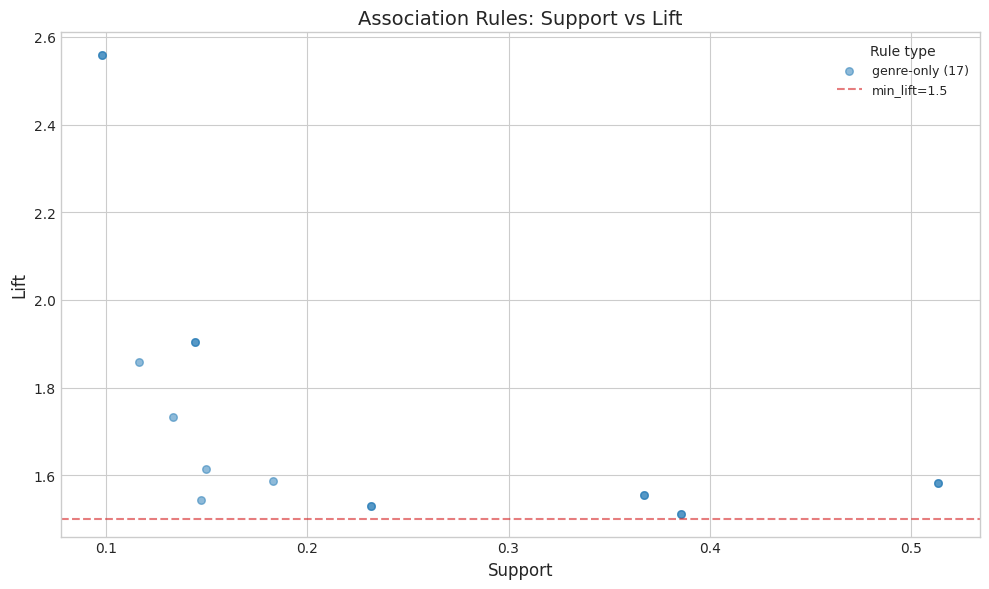

Saved → /mnt/d/mse/nguyen_sy_hung_codebases/movielens-story-modules-b/data/story-module-outputs/story_b/preset_C_genre_tag_full/20260227_043426/figures/rule_support_vs_lift.png


In [104]:
#  8a: Support vs Lift scatter ─
fig, ax = plt.subplots(figsize=(10, 6))

# Use Matplotlib's default color cycle (avoids brittle hard-coded hex colors)
cycle_colors = plt.rcParams.get("axes.prop_cycle").by_key().get("color", [])
rule_types = ["genre-only", "movie-only", "tag-only", "cross-type"]

for i, rtype in enumerate(rule_types):
    if rtype not in set(rules["rule_type"]):
        continue
    grp = rules[rules["rule_type"] == rtype]
    ax.scatter(
        grp["support"], grp["lift"],
        alpha=0.5, s=30,
        color=(cycle_colors[i % len(cycle_colors)] if cycle_colors else None),
        label=f"{rtype} ({len(grp):,})",
    )

ax.axhline(y=MIN_LIFT, color="C3", linestyle="--", alpha=0.6, label=f"min_lift={MIN_LIFT}")
ax.set_xlabel("Support", fontsize=12)
ax.set_ylabel("Lift", fontsize=12)
ax.set_title("Association Rules: Support vs Lift", fontsize=14)
ax.legend(title="Rule type", fontsize=9)

plt.tight_layout()
fig.savefig(OUT_FIGURES / "rule_support_vs_lift.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved → {OUT_FIGURES / 'rule_support_vs_lift.png'}")

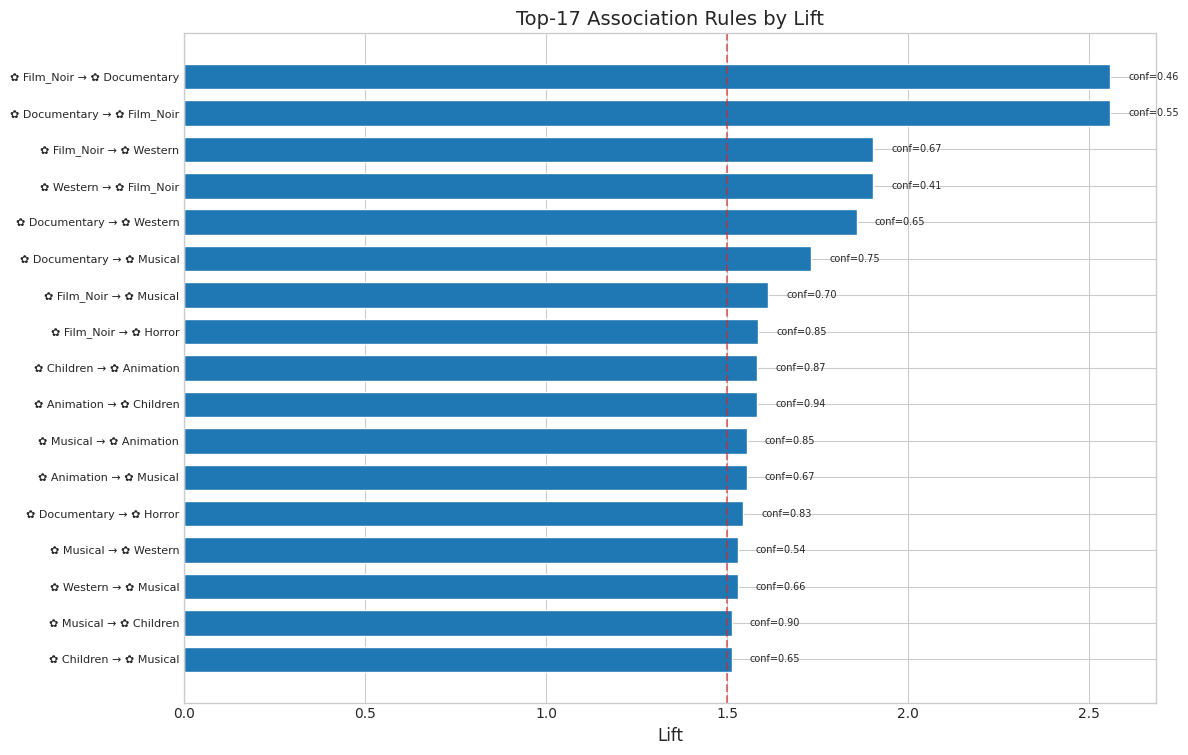

Saved → /mnt/d/mse/nguyen_sy_hung_codebases/movielens-story-modules-b/data/story-module-outputs/story_b/preset_C_genre_tag_full/20260227_043426/figures/top_rules_table.png


In [105]:
#  8b: Top rules bar chart ─
top_rules_plot = rules_hr.head(min(TOP_N_RULES_DISPLAY, len(rules_hr))).copy()
top_rules_plot = top_rules_plot.iloc[::-1]  # reverse for horizontal bar

fig, ax = plt.subplots(figsize=(12, max(6, len(top_rules_plot) * 0.45)))

bars = ax.barh(
    range(len(top_rules_plot)),
    top_rules_plot["lift"],
    edgecolor="white",
    height=0.7,
)

# Truncate long labels
labels = []
for rule_str in top_rules_plot["rule_decoded"]:
    labels.append(rule_str[:80] + "..." if len(rule_str) > 80 else rule_str)

ax.set_yticks(range(len(top_rules_plot)))
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel("Lift", fontsize=12)
ax.set_title(f"Top-{len(top_rules_plot)} Association Rules by Lift", fontsize=14)
ax.axvline(x=MIN_LIFT, color="C3", linestyle="--", alpha=0.6)

# Add confidence annotation on bars
for i, (_, row) in enumerate(top_rules_plot.iterrows()):
    ax.text(
        row["lift"] + 0.05, i,
        f"conf={row['confidence']:.2f}",
        va="center", fontsize=7,
    )

plt.tight_layout()
fig.savefig(OUT_FIGURES / "top_rules_table.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved → {OUT_FIGURES / 'top_rules_table.png'}")

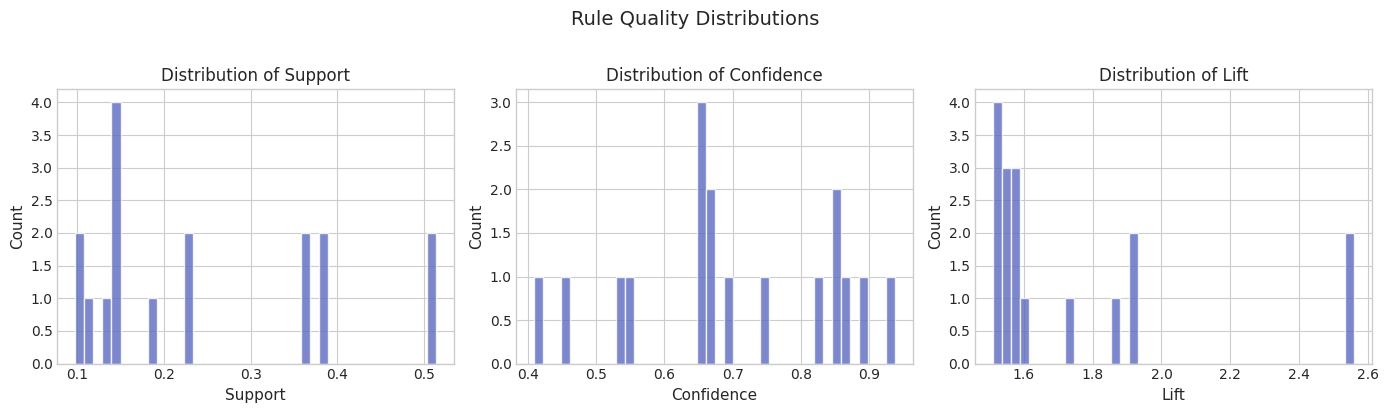

In [106]:
#  8c: Confidence distribution 
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (col, label) in zip(axes, [
    ("support", "Support"),
    ("confidence", "Confidence"),
    ("lift", "Lift"),
]):
    ax.hist(rules[col], bins=40, color="#5C6BC0", edgecolor="white", alpha=0.8)
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    ax.set_title(f"Distribution of {label}", fontsize=12)

plt.suptitle("Rule Quality Distributions", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 9 - Cross-genre rule analysis

Cross-genre rules (e.g., `genre:thriller → genre:mystery`) are generally more stable  
than movie-specific rules and reveal structural patterns in viewer taste.

In [107]:
#  Focus on genre-level and cross-type rules ─
genre_rules = rules[
    rules["rule_type"].isin(["genre-only", "cross-type"])
].copy()

print(f"Genre-related rules : {len(genre_rules):,}")

if not genre_rules.empty:
    genre_rules_hr = genre_rules.copy()
    genre_rules_hr["antecedent_decoded"] = genre_rules_hr["antecedents"].apply(decode_frozenset)
    genre_rules_hr["consequent_decoded"] = genre_rules_hr["consequents"].apply(decode_frozenset)
    genre_rules_hr["rule_decoded"] = (
        genre_rules_hr["antecedent_decoded"] + " → " + genre_rules_hr["consequent_decoded"]
    )

    print(f"\nTop genre-based rules by lift:")
    for _, row in genre_rules_hr[
        ["rule_decoded", "support", "confidence", "lift"]
    ].head(10).iterrows():
        print(
            f"  {row['rule_decoded']}"
            f"  | sup={row['support']:.4f}"
            f"  conf={row['confidence']:.3f}"
            f"  lift={row['lift']:.2f}"
        )

Genre-related rules : 17

Top genre-based rules by lift:
  ✿ Film_Noir → ✿ Documentary  | sup=0.0980  conf=0.455  lift=2.56
  ✿ Documentary → ✿ Film_Noir  | sup=0.0980  conf=0.551  lift=2.56
  ✿ Film_Noir → ✿ Western  | sup=0.1440  conf=0.669  lift=1.90
  ✿ Western → ✿ Film_Noir  | sup=0.1440  conf=0.410  lift=1.90
  ✿ Documentary → ✿ Western  | sup=0.1161  conf=0.652  lift=1.86
  ✿ Documentary → ✿ Musical  | sup=0.1329  conf=0.747  lift=1.73
  ✿ Film_Noir → ✿ Musical  | sup=0.1497  conf=0.696  lift=1.61
  ✿ Film_Noir → ✿ Horror  | sup=0.1829  conf=0.850  lift=1.59
  ✿ Children → ✿ Animation  | sup=0.5137  conf=0.868  lift=1.58
  ✿ Animation → ✿ Children  | sup=0.5137  conf=0.937  lift=1.58


## 10 - Write output artifacts

Artifacts follow the Story B.1 output contract from `README.md` Appendix B.

In [108]:
#  10a: frequent_itemsets.parquet 
freq_out = freq_low.copy()
freq_out["itemset"] = freq_out["itemsets"].apply(lambda fs: sorted(fs))
freq_out = freq_out[["itemset", "support"]].sort_values("support", ascending=False)
freq_out.to_parquet(OUT_TABLES / "frequent_itemsets.parquet", index=False)

print(f"Wrote frequent_itemsets.parquet : {len(freq_out):,} itemsets")

Wrote frequent_itemsets.parquet : 190 itemsets


In [109]:
#  10b: association_rules.parquet 
rules_out = rules.copy()
rules_out["antecedent"] = rules_out["antecedents"].apply(lambda fs: sorted(fs))
rules_out["consequent"] = rules_out["consequents"].apply(lambda fs: sorted(fs))

export_cols = [
    "antecedent", "consequent",
    "support", "confidence", "lift",
    "leverage", "conviction",
    "rule_type",
]
# Only keep columns that actually exist
export_cols = [c for c in export_cols if c in rules_out.columns]
rules_out = rules_out[export_cols].sort_values("lift", ascending=False).reset_index(drop=True)
rules_out.to_parquet(OUT_TABLES / "association_rules.parquet", index=False)

print(f"Wrote association_rules.parquet : {len(rules_out):,} rules")

Wrote association_rules.parquet : 17 rules


In [110]:
#  10c: rules_human_readable.parquet ─
hr_out = rules_hr.copy()
hr_out["antecedent"] = hr_out["antecedents"].apply(lambda fs: sorted(fs))
hr_out["consequent"] = hr_out["consequents"].apply(lambda fs: sorted(fs))

hr_export_cols = [
    "antecedent", "consequent",
    "antecedent_decoded", "consequent_decoded",
    "support", "confidence", "lift",
    "rule_type",
]
hr_export_cols = [c for c in hr_export_cols if c in hr_out.columns]
hr_out = hr_out[hr_export_cols].sort_values("lift", ascending=False).reset_index(drop=True)
hr_out.to_parquet(OUT_TABLES / "rules_human_readable.parquet", index=False)

print(f"Wrote rules_human_readable.parquet : {len(hr_out):,} rules")

Wrote rules_human_readable.parquet : 17 rules


In [111]:
#  10d: summary.md 
n_baskets_raw = len(transactions)
n_baskets_mode = len(baskets_mode)
n_baskets_filtered = len(baskets_f)
vocab_raw = vocab_size
vocab_mode = len({t for b in baskets_mode for t in set(b)})
vocab_kept = len(keep)

n_rules_candidates = len(rules_candidates) if "rules_candidates" in globals() else len(rules)
n_rules_gate1 = len(rules_g1) if "rules_g1" in globals() else n_rules_candidates
n_rules_final = len(rules)

summary_lines = [
    "# Story B.1 - Basket Rules: Run Summary\n",
    f"**Timestamp:** {datetime.now(timezone.utc).isoformat()}\n",
    "## Parameters\n",
    f"| Parameter | Value |",
    f"|---|---|",
    f"| min_support (high) | {MIN_SUPPORT_HIGH} |",
    f"| min_support (low) | {MIN_SUPPORT_LOW} |",
    f"| min_confidence | {MIN_CONFIDENCE} |",
    f"| min_lift | {MIN_LIFT} |",
    f"| max_itemset_len | {MAX_ITEMSET_LEN} |",
    f"| token_family_mode | {TOKEN_FAMILY_MODE} |",
    f"| itemset_miner | {ITEMSET_MINER} |",
    f"| vocab_limits_active | {VOCAB_LIMITS_ACTIVE} |",
    f"| basket_caps_active | {BASKET_CAPS_ACTIVE} |",
    f"| top_k_movies | {TOP_K_MOVIES if VOCAB_LIMITS_ACTIVE else 'n/a'} |",
    f"| top_k_tags | {TOP_K_TAGS if VOCAB_LIMITS_ACTIVE else 'n/a'} |",
    f"| max_movies_per_basket | {MAX_MOVIES_PER_BASKET if BASKET_CAPS_ACTIVE else 'n/a'} |",
    f"| max_tags_per_basket | {MAX_TAGS_PER_BASKET if BASKET_CAPS_ACTIVE else 'n/a'} |",
    f"| gate1_enabled | {ENABLE_GATE_1} |",
    f"| gate2_enabled | {ENABLE_GATE_2} |",
    f"| gate1_min_count_ab_train | {MIN_COUNT_AB_TRAIN} |",
    f"| gate1_min_count_a_train | {MIN_COUNT_A_TRAIN} |",
    f"| gate1_max_supp_b_train | {MAX_SUPP_B_TRAIN} |",
    f"| gate2_min_conf_test | {MIN_CONF_TEST} |",
    f"| gate2_min_conf_ratio | {MIN_CONF_RATIO} |",
    f"| gate2_min_count_ab_test | {MIN_COUNT_AB_TEST} |",
    f"| gate2_test_file | {TEST_TRANSACTIONS_FILE} |",
    "\n## Data profile\n",
    f"- n_baskets_raw: {n_baskets_raw:,}",
    f"- n_baskets_mode (after family filter): {n_baskets_mode:,}",
    f"- n_baskets_filtered (after support filter): {n_baskets_filtered:,}",
    f"- vocab_raw (distinct tokens): {vocab_raw:,}",
    f"- vocab_mode (distinct tokens): {vocab_mode:,}",
    f"- vocab_kept (distinct tokens): {vocab_kept:,}\n",
    "## Results\n",
    f"- **Frequent itemsets** (support ≥ {MIN_SUPPORT_LOW}): {len(freq_low):,}",
    f"- **High-support subset** (support ≥ {MIN_SUPPORT_HIGH}): {len(freq_high):,}",
    f"- **Rules (candidates)** after mining thresholds: {n_rules_candidates:,}",
    f"- **Rules after Gate 1**: {n_rules_gate1:,}",
    f"- **Rules (final)** after Gate 2 (if enabled): {n_rules_final:,}",
    f"\n### Rule type breakdown (final)\n",
]

for rtype, cnt in rules["rule_type"].value_counts().items():
    summary_lines.append(f"- {rtype}: {cnt:,}")

summary_lines.extend([
    f"\n### Top-10 rules by lift\n",
    "| Rule | Support | Confidence | Lift |",
    "|---|---|---|---|",
])

for _, row in rules_hr[["rule_decoded", "support", "confidence", "lift"]].head(10).iterrows():
    summary_lines.append(
        f"| {row['rule_decoded']} | {row['support']:.4f} | {row['confidence']:.3f} | {row['lift']:.2f} |"
    )

summary_lines.append(f"\n### Notes\n")
summary_lines.append(
    "This run uses a token-family strategy (Fix #4) before support filtering "
    "and mines only up to pairs (MAX_ITEMSET_LEN=2) for interpretability.\n"
 )
summary_lines.append(
    "Optionally, two quality gates can be applied: Gate 1 (evidence/non-triviality) "
    "and Gate 2 (test stability).\n"
 )

summary_md = "\n".join(summary_lines)
(OUT_REPORTS / "summary.md").write_text(summary_md, encoding="utf-8")

print(f"Wrote summary.md ({len(summary_lines)} lines)")

Wrote summary.md (58 lines)


In [112]:
#  10e: run_manifest.json 
n_rules_candidates = len(rules_candidates) if "rules_candidates" in globals() else len(rules)
n_rules_gate1 = len(rules_g1) if "rules_g1" in globals() else n_rules_candidates
n_rules_final = len(rules)

manifest = {
    "story": "B",
    "method": "fp_growth",
    "inputs": {
        "transactions_train_reduced": str(TABLE_DIR / "transactions_train_reduced.parquet"),
        "dim_movies_clean": str(TABLE_DIR / "dim_movies_clean.parquet"),
        "n_baskets_raw": int(len(transactions)),
        "n_baskets_mode": int(len(baskets_mode)),
        "n_baskets_filtered": int(len(baskets_f)),
        "vocab_raw": int(vocab_size),
        "vocab_kept": int(len(keep)),
    },
    "parameters": {
        "itemset_miner": ITEMSET_MINER,
        "min_support_high": MIN_SUPPORT_HIGH,
        "min_support_low": MIN_SUPPORT_LOW,
        "min_confidence": MIN_CONFIDENCE,
        "min_lift": MIN_LIFT,
        "max_itemset_len": MAX_ITEMSET_LEN,
        "token_family_mode": TOKEN_FAMILY_MODE,
        "control_toggles": {
            "enable_vocab_limits": bool(ENABLE_VOCAB_LIMITS),
            "enable_basket_caps": bool(ENABLE_BASKET_CAPS),
        },
        "control_active": {
            "vocab_limits_active": bool(VOCAB_LIMITS_ACTIVE),
            "basket_caps_active": bool(BASKET_CAPS_ACTIVE),
        },
        "top_k_movies": (TOP_K_MOVIES if VOCAB_LIMITS_ACTIVE else None),
        "top_k_tags": (TOP_K_TAGS if VOCAB_LIMITS_ACTIVE else None),
        "max_movies_per_basket": (MAX_MOVIES_PER_BASKET if BASKET_CAPS_ACTIVE else None),
        "max_tags_per_basket": (MAX_TAGS_PER_BASKET if BASKET_CAPS_ACTIVE else None),
        "random_seed": RANDOM_SEED,
        "gates": {
            "enable_gate_1": ENABLE_GATE_1,
            "enable_gate_2": ENABLE_GATE_2,
            "gate_1": {
                "min_count_ab_train": MIN_COUNT_AB_TRAIN,
                "min_count_a_train": MIN_COUNT_A_TRAIN,
                "max_supp_b_train": MAX_SUPP_B_TRAIN,
            },
            "gate_2": {
                "test_transactions_file": TEST_TRANSACTIONS_FILE,
                "min_conf_test": MIN_CONF_TEST,
                "min_conf_ratio": MIN_CONF_RATIO,
                "min_count_ab_test": MIN_COUNT_AB_TEST,
            },
        },
    },
    "outputs": {
        "frequent_itemsets_low": int(len(freq_low)),
        "frequent_itemsets_high": int(len(freq_high)),
        "rules_candidates": int(n_rules_candidates),
        "rules_after_gate_1": int(n_rules_gate1),
        "rules_final": int(n_rules_final),
        "rules_human_readable": int(len(hr_out)),
    },
    "timestamp": datetime.now(timezone.utc).isoformat(),
    "notebook": "story_modules/B_basket_rules.ipynb",
}

with open(OUT_REPORTS / "run_manifest.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2, default=str)

print("Wrote run_manifest.json")
print(json.dumps(manifest, indent=2, default=str))

Wrote run_manifest.json
{
  "story": "B",
  "method": "fp_growth",
  "inputs": {
    "transactions_train_reduced": "/mnt/d/mse/nguyen_sy_hung_codebases/movielens-story-modules-b/data/preprocessed-data/tables/transactions_train_reduced.parquet",
    "dim_movies_clean": "/mnt/d/mse/nguyen_sy_hung_codebases/movielens-story-modules-b/data/preprocessed-data/tables/dim_movies_clean.parquet",
    "n_baskets_raw": 316347,
    "n_baskets_mode": 316336,
    "n_baskets_filtered": 316335,
    "vocab_raw": 66979,
    "vocab_kept": 19
  },
  "parameters": {
    "itemset_miner": "fpgrowth",
    "min_support_high": 0.01,
    "min_support_low": 0.01,
    "min_confidence": 0.4,
    "min_lift": 1.5,
    "max_itemset_len": 2,
    "token_family_mode": "genre_tag",
    "control_toggles": {
      "enable_vocab_limits": true,
      "enable_basket_caps": true
    },
    "control_active": {
      "vocab_limits_active": true,
      "basket_caps_active": true
    },
    "top_k_movies": 600,
    "top_k_tags": 600,

## 11 - Final verification

In [113]:
#  Verify all output artifacts exist 
expected = [
    OUT_TABLES / "frequent_itemsets.parquet",
    OUT_TABLES / "association_rules.parquet",
    OUT_TABLES / "rules_human_readable.parquet",
    OUT_REPORTS / "run_manifest.json",
    OUT_REPORTS / "summary.md",
    OUT_FIGURES / "rule_support_vs_lift.png",
    OUT_FIGURES / "top_rules_table.png",
]

print("Output artifact checklist:")
all_ok = True
for path in expected:
    exists = path.exists()
    status = "✔" if exists else "✗"
    size = f"({path.stat().st_size:,} bytes)" if exists else ""
    print(f"  {status} {path.relative_to(REPO_ROOT)} {size}")
    all_ok = all_ok and exists

if all_ok:
    print("\n✔ All Story B.1 artifacts written successfully!")
else:
    print("\nWarning: Some artifacts are missing - check cells above for errors.")

Output artifact checklist:
  ✔ data/story-module-outputs/story_b/preset_C_genre_tag_full/20260227_043426/tables/frequent_itemsets.parquet (4,077 bytes)
  ✔ data/story-module-outputs/story_b/preset_C_genre_tag_full/20260227_043426/tables/association_rules.parquet (6,198 bytes)
  ✔ data/story-module-outputs/story_b/preset_C_genre_tag_full/20260227_043426/tables/rules_human_readable.parquet (6,224 bytes)
  ✔ data/story-module-outputs/story_b/preset_C_genre_tag_full/20260227_043426/reports/run_manifest.json (1,763 bytes)
  ✔ data/story-module-outputs/story_b/preset_C_genre_tag_full/20260227_043426/reports/summary.md (2,273 bytes)
  ✔ data/story-module-outputs/story_b/preset_C_genre_tag_full/20260227_043426/figures/rule_support_vs_lift.png (61,441 bytes)
  ✔ data/story-module-outputs/story_b/preset_C_genre_tag_full/20260227_043426/figures/top_rules_table.png (170,244 bytes)

✔ All Story B.1 artifacts written successfully!


In [114]:
#  Quick sanity read-back 
rules_check = pd.read_parquet(OUT_TABLES / "association_rules.parquet")
print(f"Read-back association_rules.parquet: {len(rules_check):,} rules")
print(f"Columns: {list(rules_check.columns)}")
rules_check.head(5)

Read-back association_rules.parquet: 17 rules
Columns: ['antecedent', 'consequent', 'support', 'confidence', 'lift', 'leverage', 'conviction', 'rule_type']


,antecedent,consequent,support,confidence,lift,leverage,conviction,rule_type
0,[genre:film_noir],[genre:documentary],0.097975,0.455144,2.558014,0.059674,1.508786,genre-only
1,[genre:documentary],[genre:film_noir],0.097975,0.550644,2.558014,0.059674,1.746361,genre-only
2,[genre:film_noir],[genre:western],0.143983,0.668874,1.904434,0.068379,1.959318,genre-only
3,[genre:western],[genre:film_noir],0.143983,0.409953,1.904434,0.068379,1.329958,genre-only
4,[genre:documentary],[genre:western],0.116095,0.652483,1.857764,0.053603,1.866903,genre-only
